In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation,Dense,Flatten,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)
%matplotlib inline

In [439]:
extract_path = "/content/drive/MyDrive/wheat_leaf_generated_modified"
if os.path.exists(extract_path):
    print("Extracted files:", os.listdir(extract_path))
else:
    print("Extraction failed or path incorrect.")

Extracted files: ['Validation', 'Training', 'Testing']


In [440]:
for root, dirs, files in os.walk("/content/drive/MyDrive/wheat_leaf_generated_mdified"):
    print(root, dirs, files)

In [441]:
training_path='/content/drive/MyDrive/wheat_leaf_generated_modified/Training'
validation_path='/content/drive/MyDrive/wheat_leaf_generated_modified/Validation'
testing_path='/content/drive/MyDrive/wheat_leaf_generated_modified/Testing'

In [442]:
print("Training path:", training_path)
print("Validation path:", validation_path)
print("Testing path:", testing_path)

Training path: /content/drive/MyDrive/wheat_leaf_generated_modified/Training
Validation path: /content/drive/MyDrive/wheat_leaf_generated_modified/Validation
Testing path: /content/drive/MyDrive/wheat_leaf_generated_modified/Testing


In [443]:
train_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(training_path, target_size=(224,224), classes=['Healthy Generated', 'Septoria Generated', 'Stripe Rust Generated'], batch_size=8)

valid_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(validation_path, target_size=(224,224), classes=['Healthy Generated', 'Septoria Generated', 'Stripe Rust Generated'], batch_size=8)

test_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(testing_path, target_size=(224,224), classes=['Healthy Generated', 'Septoria Generated', 'Stripe Rust Generated'], batch_size=8)

Found 240 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Found 30 images belonging to 3 classes.


In [444]:
# Preview a batch
x_batch, y_batch = next(train_batches)
print("Image shape:", x_batch.shape)
print("Pixel range (min to max):", x_batch.min(), "to", x_batch.max())


Image shape: (8, 224, 224, 3)
Pixel range (min to max): -70.939 to 94.061


In [445]:

# plots images with labels within jupyter notebook
def plots(ims, figsize=(12,6), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = len(ims)//rows if len(ims) % 2 == 0 else len(ims)//rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(titles[i], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

In [446]:
imgs, labels = next(train_batches)

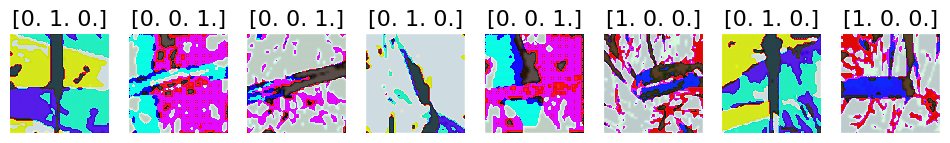

In [447]:
plots(imgs, titles=labels)

Build and train CNN

In [448]:
model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(224,224,3)),
        Flatten(),
        Dense(3, activation='softmax'),
    ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [449]:
model.compile(Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [450]:
# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',     # Metric to monitor
    patience=10,             # Number of epochs to wait after no improvement
    verbose=1,              # Verbosity mode
    restore_best_weights=True # Restore the best weights after stopping
)

In [451]:
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1577088)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │     4,731,267 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,732,163 (18.05 MB)

 Trainable params: 4,732,163 (18.05 MB)

 Non-trainable params: 0 (0.00 B)

In [452]:
model.fit(train_batches, validation_data=valid_batches, epochs=50, callbacks=[early_stopping], verbose=2)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


30/30 - 8s - 272ms/step - accuracy: 0.5500 - loss: 325.8056 - val_accuracy: 0.5333 - val_loss: 483.6973
Epoch 2/50
30/30 - 1s - 45ms/step - accuracy: 0.8208 - loss: 78.5042 - val_accuracy: 0.8000 - val_loss: 79.0009
Epoch 3/50
30/30 - 1s - 44ms/step - accuracy: 0.9375 - loss: 21.1895 - val_accuracy: 0.7667 - val_loss: 82.3055
Epoch 4/50
30/30 - 1s - 44ms/step - accuracy: 0.9667 - loss: 12.9751 - val_accuracy: 0.7000 - val_loss: 153.3346
Epoch 5/50
30/30 - 2s - 62ms/step - accuracy: 0.9625 - loss: 18.4061 - val_accuracy: 0.7667 - val_loss: 160.1104
Epoch 6/50
30/30 - 2s - 63ms/step - accuracy: 0.9875 - loss: 8.8033 - val_accuracy: 0.8000 - val_loss: 105.3507
Epoch 7/50
30/30 - 1s - 45ms/step - accuracy: 0.9875 - loss: 2.9934 - val_accuracy: 0.7333 - val_loss: 231.3501
Epoch 8/50
30/30 - 1s - 45ms/step - accuracy: 0.9917 - loss: 3.6274 - val_accuracy: 0.7333 - val_loss: 201.8816
Epoch 9/50
30/30 - 1s - 45ms/step - accuracy: 0.9958 - loss: 0.0792 - val_accuracy: 0.8667 - val_loss: 59.5535

In [453]:
print(f"Stopped at epoch: {early_stopping.stopped_epoch}")


Stopped at epoch: 19


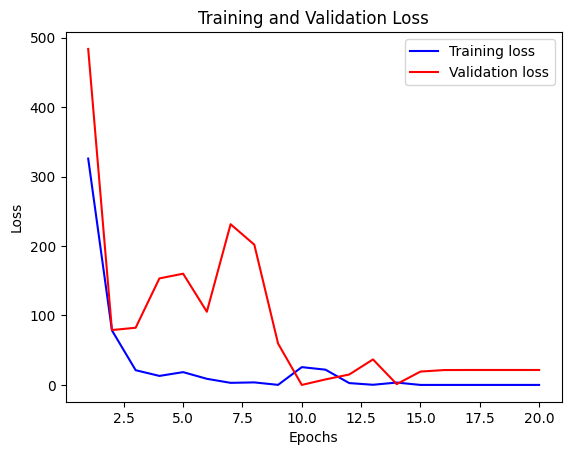

In [454]:
# prompt: plot training, testing and validation loss

import matplotlib.pyplot as plt

# Assuming 'history' object contains the training history from model.fit
# history = model.fit(...)

# Access the loss values
training_loss = model.history.history['loss']
validation_loss = model.history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(training_loss) + 1)  # Assuming epochs are available

plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


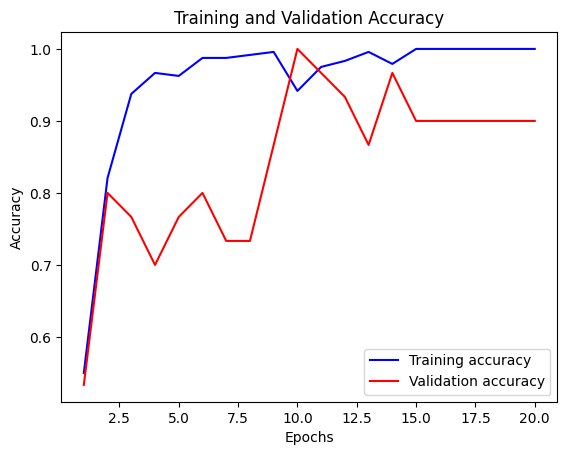

In [455]:
# Plot training and validation accuracy
training_accuracy = model.history.history['accuracy']
validation_accuracy = model.history.history['val_accuracy']

plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [456]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Training Loss: 7.3914
Training Accuracy: 97.50%
Validation Loss: 0.0000
Validation Accuracy: 100.00%
Test Loss: 97.2371
Test Accuracy: 83.33%


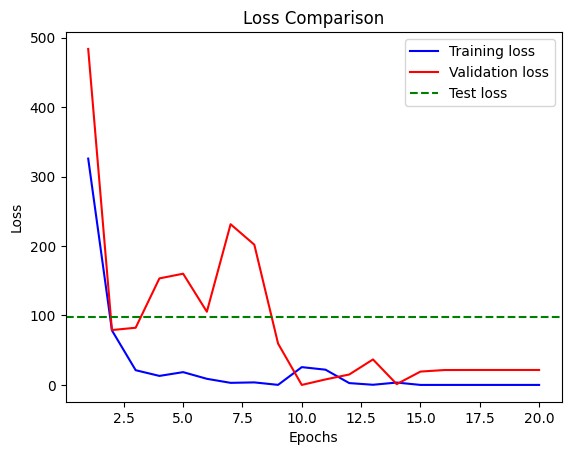

In [457]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

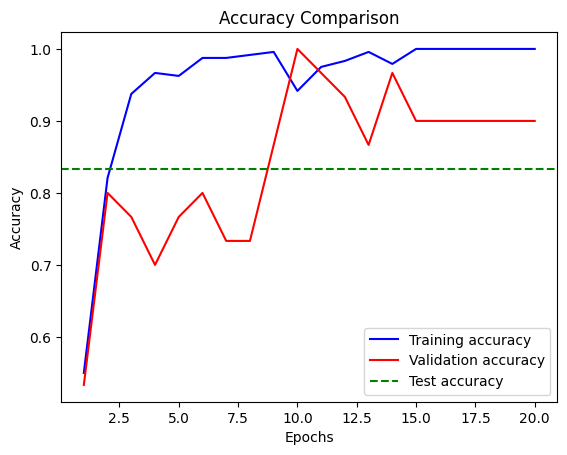

In [458]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [459]:
test_imgs, test_labels = next(test_batches)

# Get the model predictions
predictions = model.predict(test_imgs)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Print actual vs predicted labels (indices)
print(f"Actual labels: {test_labels}")
print(f"Predicted labels (indices): {predicted_classes}")

# Optionally, print the class names:
class_names = ['Healthy', 'Septoria', 'Stripe_rust']
predicted_class_names = [class_names[i] for i in predicted_classes]
print(f"Predicted class names: {predicted_class_names}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
Actual labels: [[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]
Predicted labels (indices): [1 0 2 2 0 2 0 1]
Predicted class names: ['Septoria', 'Healthy', 'Stripe_rust', 'Stripe_rust', 'Healthy', 'Stripe_rust', 'Healthy', 'Septoria']


Predict


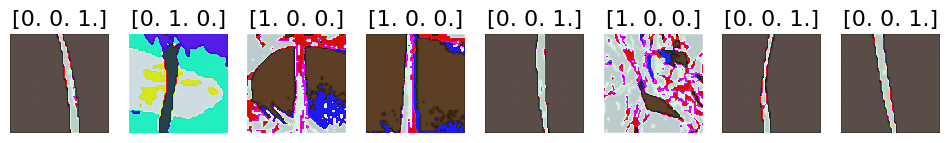

In [460]:
test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [461]:
test_labels = test_labels[:,0]
test_labels

array([0., 0., 1., 1., 0., 1., 0., 0.], dtype=float32)

In [462]:
predictions = model.predict(test_batches, steps=1, verbose=0)

In [463]:

predictions.round(2)

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]], dtype=float32)

Build Fine-tuned VGG16 model

In [468]:
vgg16_model = keras.applications.vgg16.VGG16()

In [469]:
vgg16_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [470]:
type(vgg16_model)

keras.src.models.functional.Functional

In [471]:

model = Sequential()
for layer in vgg16_model.layers:
    model.add(layer)

In [472]:

model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [473]:
model.layers.pop()

<Dense name=predictions, built=True>

In [474]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [475]:
for layer in model.layers:
    layer.trainable = False

In [476]:
model.add(Dense(3, activation='softmax'))

In [477]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │         3,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,360,547 (527.80 MB)

 Trainable params: 3,003 (11.73 KB)

 Non-trainable params: 138,357,544 (527.79 MB)

Train the fine-tuned VGG16 model

In [478]:
model.compile(Adam(learning_rate=.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [479]:
history = model.fit(train_batches, steps_per_epoch=4,
                    validation_data=valid_batches, epochs=50, callbacks=[early_stopping], verbose=2)


Epoch 1/50
4/4 - 12s - 3s/step - accuracy: 0.3750 - loss: 1.0985 - val_accuracy: 0.2333 - val_loss: 1.0988
Epoch 2/50
4/4 - 0s - 108ms/step - accuracy: 0.4375 - loss: 1.0977 - val_accuracy: 0.2333 - val_loss: 1.0987
Epoch 3/50
4/4 - 0s - 108ms/step - accuracy: 0.4062 - loss: 1.0976 - val_accuracy: 0.2333 - val_loss: 1.0986
Epoch 4/50
4/4 - 0s - 110ms/step - accuracy: 0.3750 - loss: 1.0978 - val_accuracy: 0.2333 - val_loss: 1.0986
Epoch 5/50
4/4 - 0s - 110ms/step - accuracy: 0.4375 - loss: 1.0980 - val_accuracy: 0.2333 - val_loss: 1.0985
Epoch 6/50
4/4 - 1s - 248ms/step - accuracy: 0.4688 - loss: 1.0964 - val_accuracy: 0.2667 - val_loss: 1.0984
Epoch 7/50
4/4 - 0s - 112ms/step - accuracy: 0.5625 - loss: 1.0965 - val_accuracy: 0.2667 - val_loss: 1.0983
Epoch 8/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4/4 - 0s - 103ms/step - accuracy: 0.6875 - loss: 1.0961 - val_accuracy: 0.2667 - val_loss: 1.0983
Epoch 9/50
4/4 - 7s - 2s/step - accuracy: 0.4688 - loss: 1.0969 - val_accuracy: 0.3000 - val_loss: 1.0982
Epoch 10/50
4/4 - 0s - 113ms/step - accuracy: 0.4062 - loss: 1.0981 - val_accuracy: 0.3000 - val_loss: 1.0981
Epoch 11/50
4/4 - 1s - 242ms/step - accuracy: 0.5312 - loss: 1.0966 - val_accuracy: 0.3333 - val_loss: 1.0981
Epoch 12/50
4/4 - 0s - 109ms/step - accuracy: 0.5312 - loss: 1.0955 - val_accuracy: 0.3333 - val_loss: 1.0980
Epoch 13/50
4/4 - 0s - 111ms/step - accuracy: 0.4375 - loss: 1.0979 - val_accuracy: 0.3333 - val_loss: 1.0980
Epoch 14/50
4/4 - 0s - 114ms/step - accuracy: 0.5938 - loss: 1.0959 - val_accuracy: 0.3333 - val_loss: 1.0979
Epoch 15/50
4/4 - 1s - 247ms/step - accuracy: 0.6250 - loss: 1.0959 - val_accuracy: 0.3667 - val_loss: 1.0978
Epoch 16/50
4/4 - 0s - 102ms/step - accuracy: 0.6875 - loss: 1.0943 - val_accuracy: 0.3333 - val_loss: 1.0978
Epoch 17/50
4/4 - 0s - 125

In [480]:
!nvidia-smi

Sat Apr 19 18:03:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             39W /   70W |   14070MiB /  15360MiB |     17%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

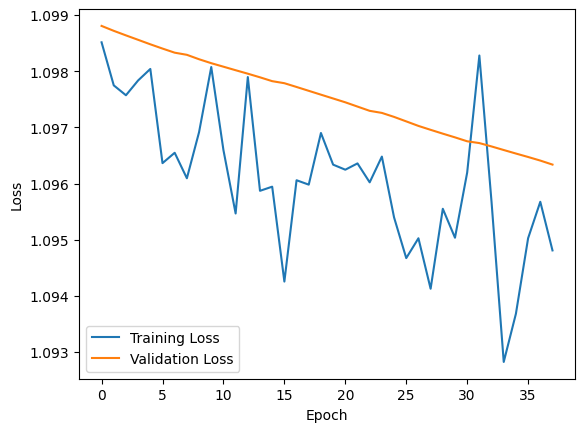

In [481]:
# prompt: Plot training and validation loss

# Plot training and validation loss
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


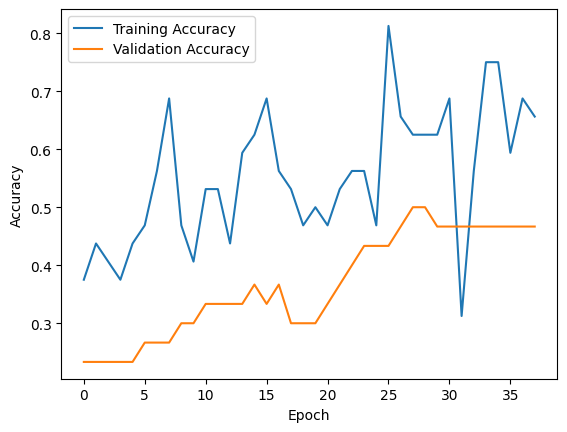

In [482]:
# prompt: plot training an validation accuracy

# Plot training and validation accuracy
plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Predict using fine-tuned VGG16 model

In [483]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss on VGG16: {train_loss:.4f}")
print(f"Training Accuracy on VGG16: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss on VGG16: {val_loss:.4f}")
print(f"Validation Accuracy on VGG16: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss on VGG16: {test_loss:.4f}")
print(f"Test Accuracy on VGG16: {test_accuracy*100:.2f}%")


Training Loss on VGG16: 1.0953
Training Accuracy on VGG16: 62.92%
Validation Loss on VGG16: 1.0970
Validation Accuracy on VGG16: 50.00%
Test Loss on VGG16: 1.0972
Test Accuracy on VGG16: 33.33%


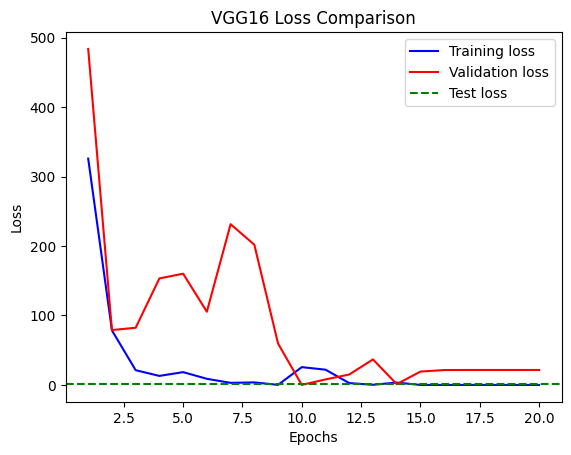

In [484]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('VGG16 Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

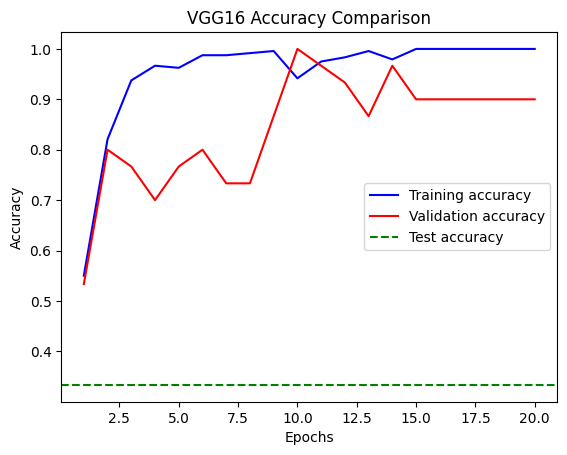

In [485]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('VGG16 Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

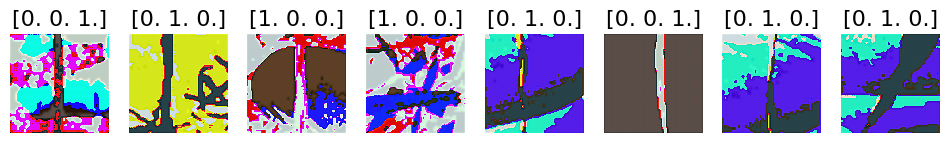

In [486]:

test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [487]:
test_labels = test_labels[:,0]
test_labels

array([0., 0., 1., 1., 0., 0., 0., 0.], dtype=float32)



```
# This is formatted as code
```



Histogram